In [5]:
import numpy as np 
import matplotlib.pyplot as plt 
from collections import Counter 

In [11]:
points = {"blue": [[2,4], [1,3], [3,2], [2,3], [2,1]], 
        "red":[[5,6], [4,5], [4,6], [6,6], [5,4]] }

In [13]:
 new_point = [3,3]

blue


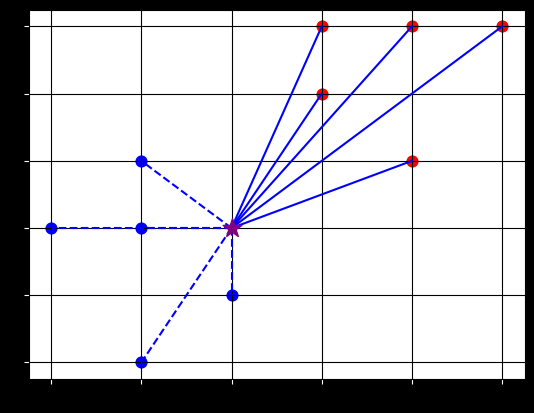

In [56]:
def eulclidean_distance(p,q):
    np.sqrt( np.sum((np.array(p)- np.array(q)) ** 2)) 


class KnearestNeighbors: 
    def __init__(self, k = 3): 
        self.k = k 
        self.point = None 
    def fit(self, points): 
        self.points = points
    def predict(self, new_point):
        distances = []

        for category in self.points: 
            for point in self.points[category]: 
                distance = eulclidean_distance(point, new_point) 
                distances.append([distance, category])

            categories = [category[1] for category in sorted(distances)[:self.k ]]
            result = Counter(categories).most_common(1)[0][0]

            return result 

clf = KnearestNeighbors()
clf.fit(points)
print(clf.predict(new_point))


ax = plt.subplot()
ax.grid(True, color = "black")
ax.figure.set_facecolor('black')
ax.tick_params(axis="x", color ='white' )
ax.tick_params(axis="y", color = 'white')

for point in points["blue"]: 
    ax.scatter(point[0], point[1], color ="blue", s = 60 ) 
    
for point in points["red"]: 
    ax.scatter(point[0], point[1], color ="red", s = 60 ) 

new_class = clf.predict(new_point)
color = 'green' if new_class == "red" else "purple"

ax.scatter(new_point[0], new_point[1], color = color, marker = "*", s = 200, zorder = 100) 

for point in points['blue']: 
    ax.plot([new_point[0], point[0]], [new_point[1],point[1]], color = "blue", linestyle = "--")
for point in points['red']: 
    ax.plot([new_point[0], point[0]], [new_point[1],point[1]], color = "blue")

plt.show()

            
        